# Apple Products Pricing (2020–2026) — Exploratory Data Analysis

## Business Problem

**Price retention / depreciation modeling**

- **Problem:** Trade-in, leasing, insurance, and refurbishing businesses need to know residual value — how much of its value a product retains N months after launch.
- **Hypothesis:** Apple products depreciate along category-specific exponential curves; condition applies a stable multiplier; festival events cause temporary, recoverable dips.
- **Target:** `Retention_Ratio = Current_Price_USD / Launch_Price_USD`. Predicted price = ratio × known launch price.

Both targets are profiled below: `Current_Price_USD` (raw price, for reference) and `Retention_Ratio` (primary modeling target).

| Section | Contents |
|---|---|
| 0 | Load, leakage drop, feature engineering |
| 1 | Dataset overview and completeness audit |
| 2 | Target profiling: `Current_Price_USD` and `Retention_Ratio` |
| 3 | Feature distributions, relationships to target, cardinality assessment |
| 4 | Temporal patterns: depreciation curves, seasonality, `Reviews_Count` check |
| 5 | Data quality flags and feature-selection summary |

## 0. Load, leakage drop, and feature engineering

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TARGET = 'Current_Price_USD'   # raw price (reference)
RATIO = 'Retention_Ratio'      # primary modeling target

df = pd.read_csv('apple_products_pricing_2020_2026.csv', parse_dates=['Date'])
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head()

Loaded 80,000 rows x 14 columns | 2020-09-19 to 2026-07-31


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


> **Note — columns dropped for leakage / redundancy.**
> `Current_Price_INR` is the target expressed in another currency (direct leakage).
> `Discount_Pct` is arithmetically derived from the target: `(1 − Current_Price_USD / Launch_Price_USD) × 100` (leakage).
> `Launch_Price_INR` is collinear with `Launch_Price_USD` (redundant — keep the USD version only).
> The cell below prints the evidence, then drops all three so no downstream analysis can accidentally use them.

In [21]:
LEAK_COLS = ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']

# Evidence before dropping
print(f"corr(Current_Price_USD, Current_Price_INR)  = {df[TARGET].corr(df['Current_Price_INR']):.4f}  -> target in INR (leakage)")
recon = (1 - df[TARGET] / df['Launch_Price_USD']) * 100
print(f"Discount_Pct vs (1 - Current/Launch)*100    : max abs diff = {(recon - df['Discount_Pct']).abs().max():.4f}  -> derived from target (leakage)")
print(f"corr(Launch_Price_USD, Launch_Price_INR)    = {df['Launch_Price_USD'].corr(df['Launch_Price_INR']):.4f}  -> redundant")

df = df.drop(columns=LEAK_COLS)
print(f"\nDropped {LEAK_COLS}")
print(f"Remaining columns: {list(df.columns)}")

corr(Current_Price_USD, Current_Price_INR)  = 0.9951  -> target in INR (leakage)
Discount_Pct vs (1 - Current/Launch)*100    : max abs diff = 0.0514  -> derived from target (leakage)
corr(Launch_Price_USD, Launch_Price_INR)    = 1.0000  -> redundant

Dropped ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']
Remaining columns: ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']


### Feature engineering

- **`Retention_Ratio`** — the modeling target: `Current_Price_USD / Launch_Price_USD`.
- **`days_since_launch`** — per-model depreciation clock, derived as days since the model's first appearance in the data (no launch-date column exists; first listing date is the self-contained proxy).
- **Model_Name-agnostic attributes** parsed from the name string, so the model can score products not in the training data (e.g., *iPhone 19 128GB*): `storage_gb`, `variant_tier` (Pro Max / Pro / Air / mini / ...), `generation` (iPhone 17 → 17, Watch Series 6 → 6, "(9th Gen)" → 9, Apple-silicon M3 → 3 as fallback; Roman numerals like Series X stay NaN — parsing is heuristic).
- **`Sale_Event` cleanup** — in the raw data, "no event" is stored as NaN (~92% of rows); it is filled with the explicit category `'None'` first, and `is_sale_event` derived from it.
- **Calendar features** — `month`, `is_sale_event`.

In [22]:
df[RATIO] = df[TARGET] / df['Launch_Price_USD']

launch_date = df.groupby('Model_Name')['Date'].transform('min')
df['days_since_launch'] = (df['Date'] - launch_date).dt.days

# Sale_Event: NaN means "no event" -> make it an explicit category before deriving features
n_nan = df['Sale_Event'].isna().sum()
df['Sale_Event'] = df['Sale_Event'].fillna('None')
print(f"Sale_Event: {n_nan:,} NaN rows ({n_nan/len(df)*100:.1f}%) interpreted as 'no event' and filled with 'None'")

df['month'] = df['Date'].dt.month
df['is_sale_event'] = df['Sale_Event'].ne('None').astype(int)

# ---- Model_Name-agnostic parsed attributes ----
mn = df['Model_Name'].astype(str)
gb = mn.str.extract(r'(\d+)\s*GB', expand=False).astype(float)
tb = mn.str.extract(r'(\d+)\s*TB', expand=False).astype(float) * 1024
df['storage_gb'] = gb.fillna(tb)

TIERS = ['Pro Max', 'Ultra', 'Pro', 'Plus', 'Max', 'Air', 'mini', 'SE']  # order matters: match most specific first
def parse_tier(name):
    for t in TIERS:
        if t in name:
            return t
    return 'base'
df['variant_tier'] = mn.map(parse_tier)

# generation: model number (iPhone 15, Series 6) -> ordinal "(9th Gen)" -> Apple-silicon chip (M1/M2/...)
gen_named   = mn.str.extract(r'(?:iPhone|Series|AirPods)\s+(\d+)', expand=False)
gen_ordinal = mn.str.extract(r'\((\d+)(?:st|nd|rd|th)\s+Gen\)', expand=False)
gen_chip    = mn.str.extract(r'\bM(\d+)\b', expand=False)
df['generation'] = gen_named.fillna(gen_ordinal).fillna(gen_chip).astype(float)

print("\nParsed attributes per unique model (heuristic — verify any NaNs are acceptable):")
df[['Model_Name', 'Product_Category', 'variant_tier', 'storage_gb', 'generation']].drop_duplicates('Model_Name').reset_index(drop=True)

Sale_Event: 73,351 NaN rows (91.7%) interpreted as 'no event' and filled with 'None'

Parsed attributes per unique model (heuristic — verify any NaNs are acceptable):


,Model_Name,Product_Category,variant_tier,storage_gb,generation
0,Apple Watch Series 6 (44mm),Watch,base,NaN,6.0
1,iPad Air (4th Gen) 64GB,iPad,Air,64.0,4.0
2,iPhone 12 64GB,iPhone,base,64.0,12.0
3,iPhone 12 Pro 128GB,iPhone,Pro,128.0,12.0
4,MacBook Air M1 256GB,Mac,Air,256.0,1.0
5,iPad Pro 11-inch (M1) 128GB,iPad,Pro,128.0,1.0
6,iPhone 13 128GB,iPhone,base,128.0,13.0
7,iPhone 13 Pro Max 256GB,iPhone,Pro Max,256.0,13.0
8,iPad (9th Gen) 64GB,iPad,base,64.0,9.0
9,Apple Watch Series 7 (45mm),Watch,base,NaN,7.0


## 1. Dataset overview and completeness audit

In [23]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_%': (df.notna().mean() * 100).round(2),
    'n_unique': df.nunique(),
    'example': df.iloc[0].astype(str),
})
overview

,dtype,non_null_%,n_unique,example
Date,datetime64[us],100.00,2130,2020-09-19 00:00:00
Platform,str,100.00,2,Flipkart
Product_Category,str,100.00,4,Watch
Model_Name,str,100.00,31,Apple Watch Series 6 (44mm)
Condition,str,100.00,2,New
Launch_Price_USD,int64,100.00,9,429
Current_Price_USD,float64,100.00,49611,435.81
Sale_Event,str,100.00,5,None
Stock_Status,str,100.00,3,In Stock
Rating,float64,100.00,12,4.7


In [24]:
# Group columns by shared missingness rate; explain which row subsets drive it
null_rate = (100 - df.notna().mean() * 100).round(2)
print("Columns grouped by % missing:")
for rate, cols in null_rate.groupby(null_rate).groups.items():
    print(f"  {rate:>6.2f}% missing -> {list(cols)}")

incomplete = null_rate[null_rate > 0].index.tolist()
if incomplete:
    for col in incomplete:
        seg = df[df[col].isna()]
        print(f"\nRows missing '{col}' — breakdown by Product_Category:")
        print(seg['Product_Category'].value_counts().to_string())
    print("\nNote: NaNs in parsed attributes (storage_gb / generation) are expected where the model name")
    print("carries no such token (e.g., MacBooks have no GB suffix); impute or flag before modeling.")
else:
    print("\nNo missing values in any column.")

Columns grouped by % missing:
    0.00% missing -> ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count', 'Retention_Ratio', 'days_since_launch', 'month', 'is_sale_event', 'variant_tier']
    9.45% missing -> ['generation']
   22.33% missing -> ['storage_gb']

Rows missing 'storage_gb' — breakdown by Product_Category:
Product_Category
Watch    17865

Rows missing 'generation' — breakdown by Product_Category:
Product_Category
Watch    7557

Note: NaNs in parsed attributes (storage_gb / generation) are expected where the model name
carries no such token (e.g., MacBooks have no GB suffix); impute or flag before modeling.


### Model × launch price map

Each model carries exactly one launch price; the pivot below shows the price points and how observations distribute across them (this also motivates why `Product_Category` alone is too coarse — several launch price points per category).

In [25]:
launch_prices = sorted(df['Launch_Price_USD'].drop_duplicates().tolist())

model_launch_map = (
    df[['Model_Name', 'Launch_Price_USD']]
      .drop_duplicates()
      .sort_values(['Launch_Price_USD', 'Model_Name'])
)
ordered_models = model_launch_map['Model_Name'].tolist()

launch_price_pivot = (
    df.pivot_table(
        index='Model_Name',
        columns='Launch_Price_USD',
        values='Current_Price_USD',
        aggfunc='count',
        fill_value=0
    )
    .reindex(index=ordered_models, columns=launch_prices, fill_value=0)
)
launch_price_pivot

Launch_Price_USD,329,429,599,799,849,999,1099,1199,1999
Model_Name,,,,,,,,,
iPad (9th Gen) 64GB,2573,0,0,0,0,0,0,0,0
Apple Watch Series 6 (44mm),0,2572,0,0,0,0,0,0,0
Apple Watch Series 7 (45mm),0,2600,0,0,0,0,0,0,0
Apple Watch Series 8 (45mm),0,2606,0,0,0,0,0,0,0
Apple Watch Series 9 (45mm),0,2530,0,0,0,0,0,0,0
Apple Watch Series X (45mm),0,2520,0,0,0,0,0,0,0
iPad Air (4th Gen) 64GB,0,0,2677,0,0,0,0,0,0
iPad Air (5th Gen) 64GB,0,0,2583,0,0,0,0,0,0
Apple Watch Ultra,0,0,0,2544,0,0,0,0,0


## 2. Target profiling — `Current_Price_USD` (reference) and `Retention_Ratio` (primary)

In [26]:
t = df[TARGET].dropna()
r = df[RATIO].dropna()

prof = pd.DataFrame({TARGET: t.describe(), RATIO: r.describe()}).T
prof['skew'] = [t.skew(), r.skew()]
prof['kurtosis'] = [t.kurt(), r.kurt()]

q1, q3 = r.quantile([.25, .75]); iqr = q3 - q1
out = (r < q1 - 1.5 * iqr) | (r > q3 + 1.5 * iqr)
print(f"{TARGET}: skew {t.skew():.2f} — strongly right-skewed raw prices")
print(f"{RATIO}: skew {r.skew():.2f} — ratio target is far better behaved")
print(f"{RATIO} IQR outliers: {out.sum():,} rows ({out.mean()*100:.2f}%)")
above = (r > 1).mean() * 100
print(f"Rows selling ABOVE launch price (ratio > 1): {above:.2f}% — scarcity premiums / price fluctuation")
prof.round(3)

Current_Price_USD: skew 1.11 — strongly right-skewed raw prices
Retention_Ratio: skew -0.25 — ratio target is far better behaved
Retention_Ratio IQR outliers: 0 rows (0.00%)
Rows selling ABOVE launch price (ratio > 1): 11.12% — scarcity premiums / price fluctuation


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Current_Price_USD,80000.0,782.770,461.674,109.930,432.930,699.740,989.112,2038.97,1.110,0.704
Retention_Ratio,80000.0,0.786,0.167,0.269,0.632,0.787,0.933,1.02,-0.245,-1.027


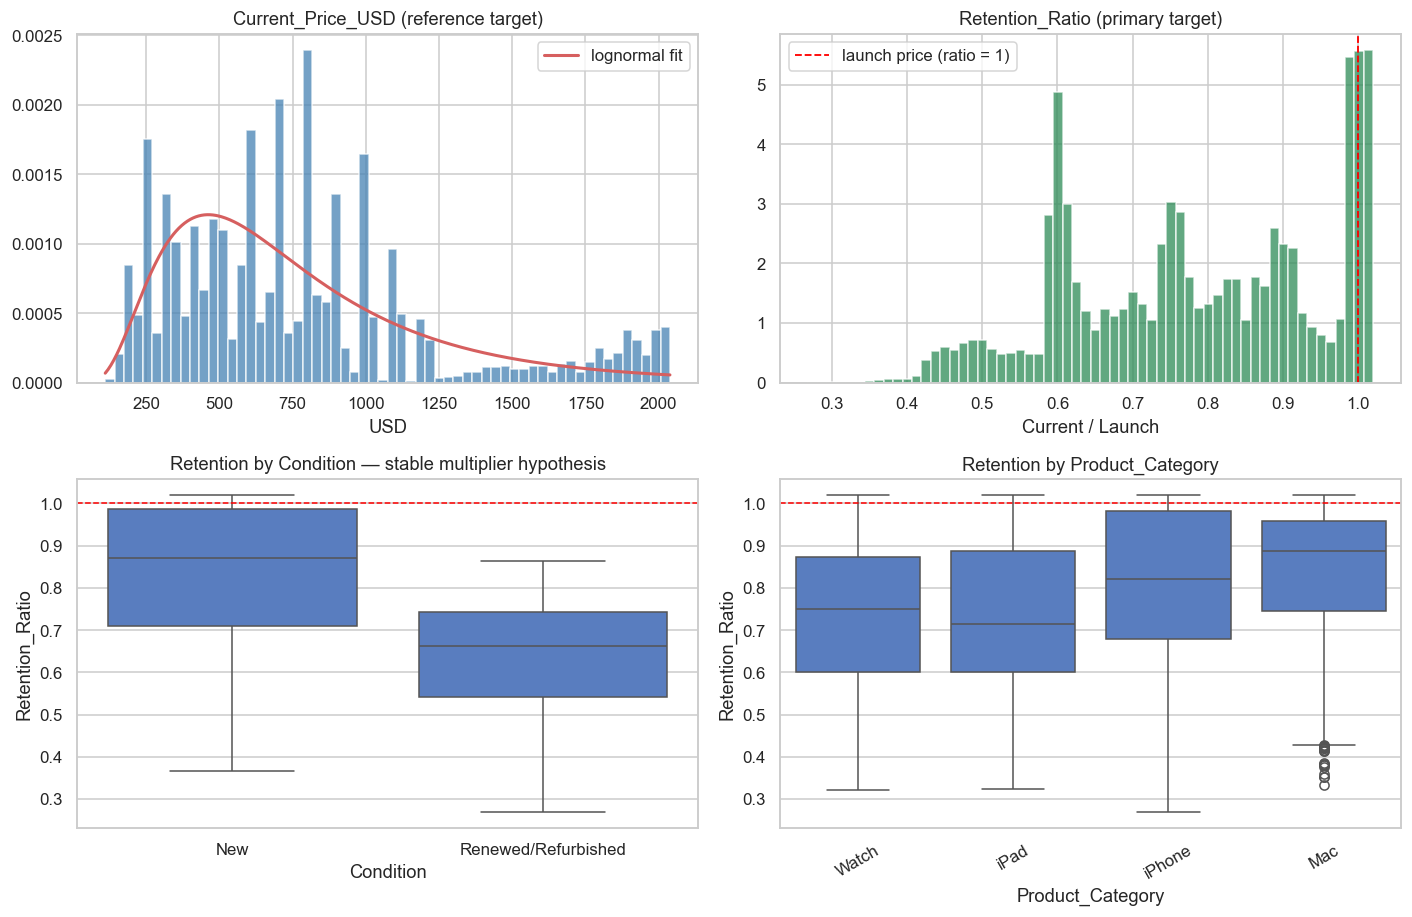

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0, 0]
ax.hist(t, bins=60, density=True, alpha=.75, color='steelblue', edgecolor='white')
shape, loc, scale = stats.lognorm.fit(t, floc=0)
xs = np.linspace(t.min(), t.max(), 400)
ax.plot(xs, stats.lognorm.pdf(xs, shape, loc, scale), 'r-', lw=2, label='lognormal fit')
ax.set(title=f'{TARGET} (reference target)', xlabel='USD')
ax.legend()

ax = axes[0, 1]
ax.hist(r, bins=60, density=True, alpha=.75, color='seagreen', edgecolor='white')
ax.axvline(1.0, color='red', ls='--', lw=1.2, label='launch price (ratio = 1)')
ax.set(title=f'{RATIO} (primary target)', xlabel='Current / Launch')
ax.legend()

sns.boxplot(data=df, x='Condition', y=RATIO, ax=axes[1, 0])
axes[1, 0].axhline(1.0, color='red', ls='--', lw=1)
axes[1, 0].set_title('Retention by Condition — stable multiplier hypothesis')

sns.boxplot(data=df, x='Product_Category', y=RATIO, ax=axes[1, 1])
axes[1, 1].axhline(1.0, color='red', ls='--', lw=1)
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].set_title('Retention by Product_Category')

plt.tight_layout()
plt.show()

**Read-out:** raw price is strongly right-skewed (log-transform territory); the retention ratio is naturally bounded and near-symmetric — a better-behaved regression target that also normalizes a $329 iPad and a $1,999 MacBook Pro onto one scale. The Condition boxplot is the first check of the *stable multiplier* hypothesis: the Renewed/Refurbished distribution should sit a roughly constant fraction below New across categories.

## 3. Feature distributions, relationships to target, and cardinality assessment

In [28]:
NUM_FEATS = ['Launch_Price_USD', 'Rating', 'Reviews_Count', 'storage_gb', 'generation',
             'days_since_launch', 'month', 'is_sale_event']
num_summary = df[NUM_FEATS].describe().T
num_summary['skew'] = df[NUM_FEATS].skew()
num_summary['distribution_flag'] = np.where(num_summary['skew'].abs() > 1, 'skewed / heavy-tailed', 'ok')
num_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,distribution_flag
Launch_Price_USD,80000.0,963.96,470.09,329.0,599.0,799.0,1199.0,1999.0,1.03,skewed / heavy-tailed
Rating,80000.0,4.45,0.27,3.8,4.3,4.4,4.7,4.9,-0.30,ok
Reviews_Count,80000.0,2406.00,1973.63,10.0,896.0,1893.5,3383.0,11526.0,1.25,skewed / heavy-tailed
storage_gb,62135.0,223.17,146.37,64.0,128.0,128.0,256.0,512.0,0.97,ok
generation,72443.0,8.17,5.45,1.0,3.0,8.0,14.0,17.0,0.16,ok
days_since_launch,80000.0,685.52,493.91,0.0,280.0,590.0,1005.0,2141.0,0.70,ok
month,80000.0,6.40,3.46,1.0,3.0,6.0,10.0,12.0,0.07,ok
is_sale_event,80000.0,0.08,0.28,0.0,0.0,0.0,0.0,1.0,3.02,skewed / heavy-tailed


In [29]:
CAT_FEATS = ['Platform', 'Product_Category', 'Model_Name', 'Condition', 'Sale_Event', 'Stock_Status', 'variant_tier']
cat_summary = pd.DataFrame({
    'cardinality': {c: df[c].nunique() for c in CAT_FEATS},
    'top_5_categories': {c: dict(df[c].value_counts().head(5)) for c in CAT_FEATS},
})
cat_summary

,cardinality,top_5_categories
Platform,2,"{'Flipkart': 40043, 'Amazon': 39957}"
Product_Category,4,"{'iPhone': 28589, 'Mac': 18020, 'Watch': 17865, 'iPad': 15526}"
Model_Name,31,"{'iPhone 14 Pro 128GB': 2734, 'iPad Air (4th Gen) 64GB': 2677, 'iPad Pro 11-inch (M1) 128GB': 2661, 'iPhone 17 128GB..."
Condition,2,"{'New': 59985, 'Renewed/Refurbished': 20015}"
Sale_Event,5,"{'None': 73351, 'Black Friday': 2497, 'Big Billion Days': 1579, 'Great Indian Festival': 1504, 'Prime Day': 1069}"
Stock_Status,3,"{'In Stock': 55034, 'Out of Stock': 13475, 'Low Stock': 11491}"
variant_tier,5,"{'base': 30867, 'Pro': 25937, 'Air': 13009, 'Pro Max': 5150, 'Ultra': 5037}"


In [30]:
# Association with BOTH targets. Spearman for numerics; eta-squared for categoricals.
def eta_squared(frame, cat, target):
    grand = frame[target].mean()
    ss_between = frame.groupby(cat)[target].agg(['count', 'mean']).eval('count * (mean - @grand) ** 2').sum()
    ss_total = ((frame[target] - grand) ** 2).sum()
    return ss_between / ss_total

num_assoc = pd.DataFrame({
    f'spearman_vs_{TARGET}': df[NUM_FEATS + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET),
    f'spearman_vs_{RATIO}': df[NUM_FEATS + [RATIO]].corr(method='spearman')[RATIO].drop(RATIO),
}).sort_values(f'spearman_vs_{RATIO}', key=lambda s: s.abs(), ascending=False)

cat_assoc = pd.DataFrame({
    f'eta2_vs_{TARGET}': {c: eta_squared(df, c, TARGET) for c in CAT_FEATS},
    f'eta2_vs_{RATIO}': {c: eta_squared(df, c, RATIO) for c in CAT_FEATS},
}).sort_values(f'eta2_vs_{RATIO}', ascending=False)

print("Numeric features (Spearman):")
print(num_assoc.round(3).to_string())
print("\nCategorical features (eta-squared: share of target variance explained):")
print(cat_assoc.round(3).to_string())

Numeric features (Spearman):
                   spearman_vs_Current_Price_USD  spearman_vs_Retention_Ratio
days_since_launch                         -0.357                       -0.721
Reviews_Count                             -0.316                       -0.649
storage_gb                                 0.864                        0.332
Launch_Price_USD                           0.920                        0.330
Rating                                     0.113                        0.283
is_sale_event                             -0.094                       -0.209
generation                                -0.198                        0.064
month                                     -0.025                       -0.045

Categorical features (eta-squared: share of target variance explained):
                  eta2_vs_Current_Price_USD  eta2_vs_Retention_Ratio
Model_Name                            0.911                    0.243
Condition                             0.031               

### Cardinality assessment: `Product_Category` vs `Model_Name` vs parsed attributes

The concern, stated explicitly:

- **`Product_Category` alone is too coarse** — different iPhone models carry different `Launch_Price_USD` (storage options, Pro vs Pro Max), so category-level encoding blurs real price positioning.
- **`Model_Name` is precise but not deployable** — the final model must be **`Model_Name`-agnostic**: it must score models that don't exist in the training data (e.g., *iPhone 19 128GB*). A one-hot or target-encoded `Model_Name` has no representation for an unseen name. It's also high-cardinality (one level per model) and, since launch price is constant within a model, partially duplicates `Launch_Price_USD`.
- **Resolution — decompose `Model_Name` into generalizable attributes:** `Product_Category` + `variant_tier` + `storage_gb` + `generation`. An unseen *iPhone 19 128GB* maps to (iPhone, base, 128, 19) — every component was seen in training. The cell below quantifies how much of `Model_Name`'s explanatory power this decomposition recovers.

In [31]:
# How much of Model_Name's signal do the agnostic attributes recover?
df['_agnostic_combo'] = (df['Product_Category'] + '|' + df['variant_tier'] + '|'
                         + df['storage_gb'].fillna(-1).astype(int).astype(str) + '|'
                         + df['generation'].fillna(-1).astype(int).astype(str))

comparison = pd.DataFrame({
    'cardinality': {
        'Product_Category': df['Product_Category'].nunique(),
        'Model_Name': df['Model_Name'].nunique(),
        'agnostic combo (cat+tier+storage+gen)': df['_agnostic_combo'].nunique(),
    },
    f'eta2_vs_{RATIO}': {
        'Product_Category': eta_squared(df, 'Product_Category', RATIO),
        'Model_Name': eta_squared(df, 'Model_Name', RATIO),
        'agnostic combo (cat+tier+storage+gen)': eta_squared(df, '_agnostic_combo', RATIO),
    },
    f'eta2_vs_{TARGET}': {
        'Product_Category': eta_squared(df, 'Product_Category', TARGET),
        'Model_Name': eta_squared(df, 'Model_Name', TARGET),
        'agnostic combo (cat+tier+storage+gen)': eta_squared(df, '_agnostic_combo', TARGET),
    },
})
print(comparison.round(3).to_string())

recovered = comparison.loc['agnostic combo (cat+tier+storage+gen)', f'eta2_vs_{RATIO}'] / \
            max(comparison.loc['Model_Name', f'eta2_vs_{RATIO}'], 1e-9) * 100
print(f"\nAgnostic attributes recover {recovered:.1f}% of Model_Name's explanatory power on {RATIO}.")
print("If close to 100%, drop Model_Name from the feature set with little cost — and gain")
print("the ability to score unseen models. Note the combo's cardinality vs Model_Name's:")
print("a gap means some models collapse to the same attribute tuple (usually harmless).")
df = df.drop(columns=['_agnostic_combo'])

                                       cardinality  eta2_vs_Retention_Ratio  eta2_vs_Current_Price_USD
Product_Category                                 4                    0.068                      0.576
Model_Name                                      31                    0.243                      0.911
agnostic combo (cat+tier+storage+gen)           30                    0.241                      0.910

Agnostic attributes recover 99.3% of Model_Name's explanatory power on Retention_Ratio.
If close to 100%, drop Model_Name from the feature set with little cost — and gain
the ability to score unseen models. Note the combo's cardinality vs Model_Name's:
a gap means some models collapse to the same attribute tuple (usually harmless).


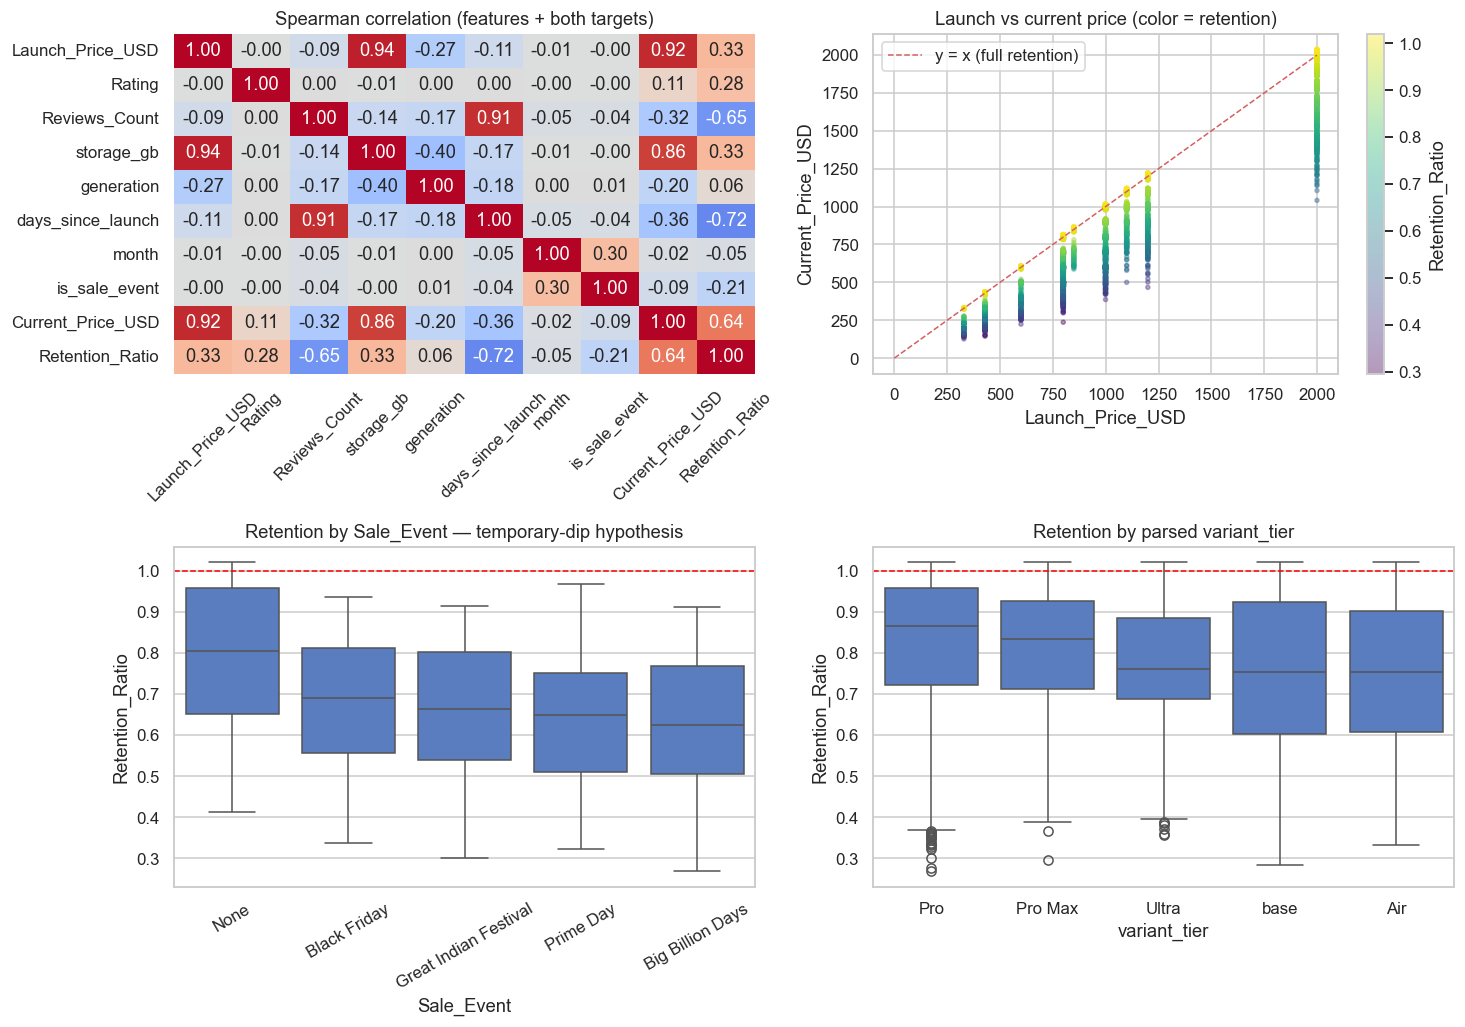

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))

corr_cols = NUM_FEATS + [TARGET, RATIO]
sns.heatmap(df[corr_cols].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0, 0], cbar=False,
            xticklabels=corr_cols, yticklabels=corr_cols)
axes[0, 0].set_title('Spearman correlation (features + both targets)')
axes[0, 0].tick_params(axis='x', rotation=45)

sample = df.sample(min(5000, len(df)), random_state=0)
sc = axes[0, 1].scatter(sample['Launch_Price_USD'], sample[TARGET],
                        c=sample[RATIO], cmap='viridis', s=7, alpha=.4)
axes[0, 1].plot([0, sample['Launch_Price_USD'].max()],
                [0, sample['Launch_Price_USD'].max()], 'r--', lw=1, label='y = x (full retention)')
axes[0, 1].set(xlabel='Launch_Price_USD', ylabel=TARGET, title='Launch vs current price (color = retention)')
axes[0, 1].legend()
plt.colorbar(sc, ax=axes[0, 1], label=RATIO)

order = df.groupby('Sale_Event')[RATIO].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Sale_Event', y=RATIO, order=order, ax=axes[1, 0])
axes[1, 0].axhline(1.0, color='red', ls='--', lw=1)
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title('Retention by Sale_Event — temporary-dip hypothesis')

sns.boxplot(data=df, x='variant_tier', y=RATIO, ax=axes[1, 1],
            order=df.groupby('variant_tier')[RATIO].median().sort_values(ascending=False).index)
axes[1, 1].axhline(1.0, color='red', ls='--', lw=1)
axes[1, 1].set_title('Retention by parsed variant_tier')

plt.tight_layout()
plt.show()

**Read-out for feature selection:** with the ratio target, `Launch_Price_USD` stops dominating (it's now the denominator) and the model is forced to learn *depreciation behavior*: age, condition, sale events, and product attributes. Check the association tables above — features that ranked high against raw price mostly via product scale (e.g., `storage_gb`) should drop in rank against `Retention_Ratio`, while `days_since_launch`, `Condition`, and `Sale_Event` should rise.

## 4. Temporal patterns — depreciation curves, seasonality, and the `Reviews_Count` check

/var/folders/4s/0hc6wdtd6x77bzllqdrs43f80000gn/T/ipykernel_50258/3651477190.py:27: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/fuyao/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


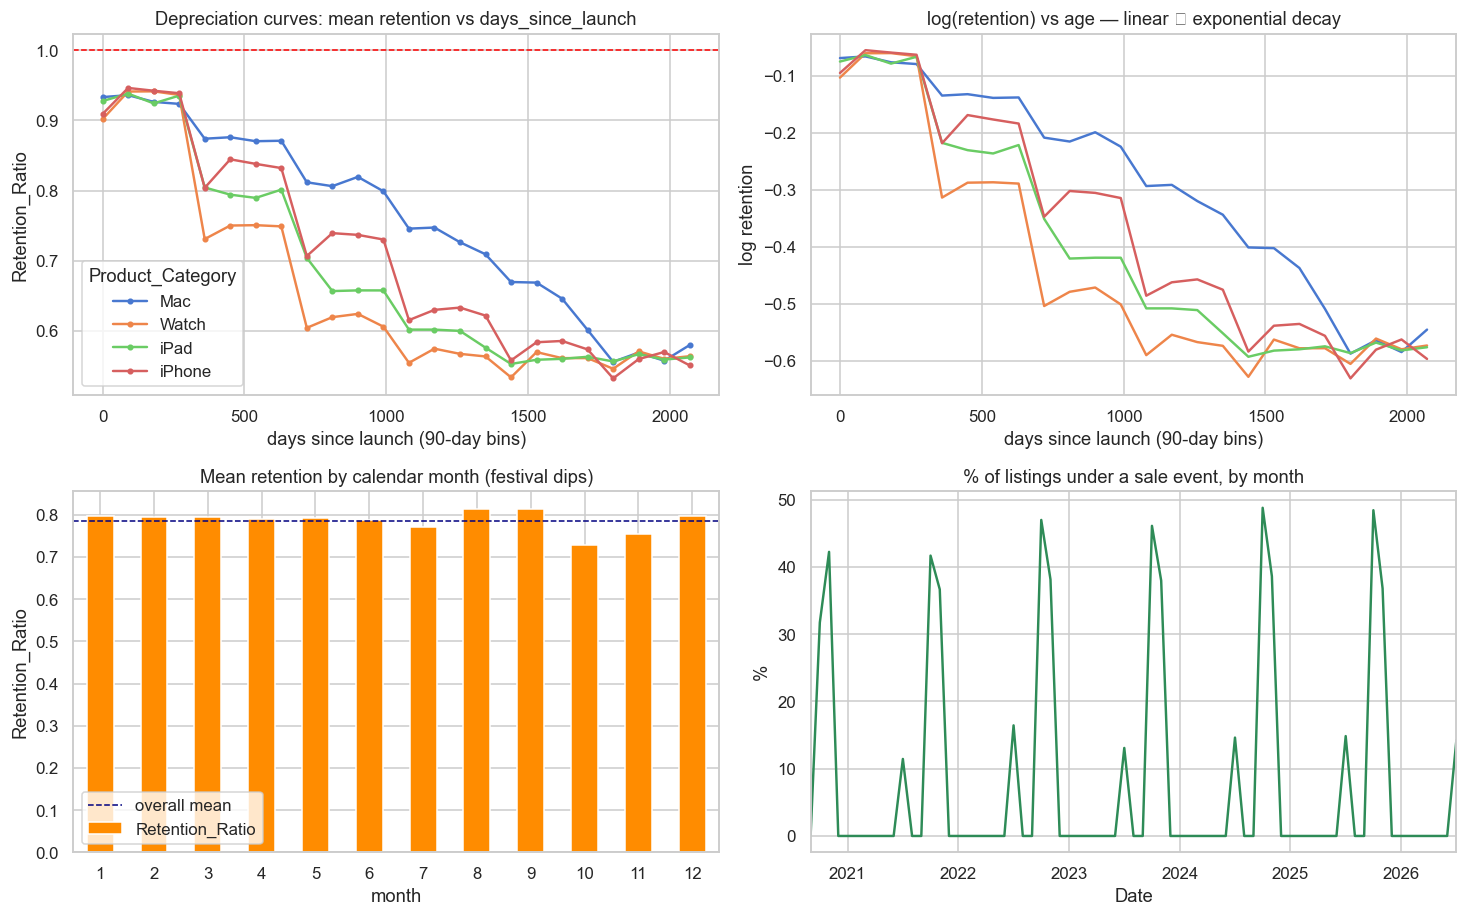

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))

# (a) Depreciation curves: mean retention vs days since launch, by category (90-day bins)
dep = (df.assign(age_bin=(df['days_since_launch'] // 90) * 90)
         .groupby(['age_bin', 'Product_Category'])[RATIO].mean().unstack())
dep.plot(ax=axes[0, 0], lw=1.6, marker='o', ms=3)
axes[0, 0].axhline(1.0, color='red', ls='--', lw=1)
axes[0, 0].set(title='Depreciation curves: mean retention vs days_since_launch',
               xlabel='days since launch (90-day bins)', ylabel=RATIO)

# (b) Same curves on log scale — exponential decay appears linear
np.log(dep.clip(lower=0.01)).plot(ax=axes[0, 1], lw=1.6, legend=False)
axes[0, 1].set(title='log(retention) vs age — linear ⇒ exponential decay',
               xlabel='days since launch (90-day bins)', ylabel='log retention')

# (c) Seasonality: mean retention by calendar month
df.groupby('month')[RATIO].mean().plot(kind='bar', ax=axes[1, 0], color='darkorange', rot=0)
axes[1, 0].axhline(df[RATIO].mean(), color='navy', ls='--', lw=1, label='overall mean')
axes[1, 0].set(title='Mean retention by calendar month (festival dips)', xlabel='month', ylabel=RATIO)
axes[1, 0].legend()

# (d) Share of listings under a sale event, by month
(df.set_index('Date')['is_sale_event'].resample('MS').mean() * 100) \
   .plot(ax=axes[1, 1], color='seagreen', lw=1.6)
axes[1, 1].set(title='% of listings under a sale event, by month', ylabel='%')

plt.tight_layout()
plt.show()

In [34]:
# Hypothesis check: exponential decay -> log(retention) ~ linear in age. Fit per-category decay rates.
print("Fitted exponential decay per category (New condition only, non-sale rows):")
base = df[(df['Condition'] == 'New') & (df['is_sale_event'] == 0) & (df['days_since_launch'] > 0)]
for cat, g in base.groupby('Product_Category'):
    slope = np.polyfit(g['days_since_launch'], np.log(g[RATIO].clip(lower=0.01)), 1)[0]
    print(f"  {cat:<10} implied annual depreciation: {(1 - np.exp(slope * 365)) * 100:6.1f}%")

print("\nCondition multiplier stability (Renewed/Refurbished vs New median retention, by category):")
cond = df.pivot_table(index='Product_Category', columns='Condition', values=RATIO, aggfunc='median')
if 'Renewed/Refurbished' in cond.columns and 'New' in cond.columns:
    cond['multiplier'] = (cond['Renewed/Refurbished'] / cond['New']).round(3)
print(cond.round(3).to_string())
print("\nIf 'multiplier' is roughly constant across categories, the stable-multiplier hypothesis holds.")

Fitted exponential decay per category (New condition only, non-sale rows):
  Mac        implied annual depreciation:    8.4%
  Watch      implied annual depreciation:   12.9%
  iPad       implied annual depreciation:   12.0%
  iPhone     implied annual depreciation:   11.1%

Condition multiplier stability (Renewed/Refurbished vs New median retention, by category):
Condition           New  Renewed/Refurbished  multiplier
Product_Category                                        
Mac               0.917                0.710       0.774
Watch             0.764                0.593       0.776
iPad              0.796                0.606       0.760
iPhone            0.884                0.679       0.768

If 'multiplier' is roughly constant across categories, the stable-multiplier hypothesis holds.


### `Reviews_Count` — is it cumulative? (synthetic-data check)

This dataset is synthetically generated, so properties a real marketplace would guarantee must be verified, not assumed. If `Reviews_Count` were real, the same `Model_Name` should accumulate reviews monotonically over time. The check below computes, per model, (a) the Spearman correlation between listing date and `Reviews_Count`, and (b) the fraction of consecutive (date-sorted) observations where the count does not decrease.

                                  n_obs  spearman_time  pct_non_decreasing
Model_Name                                                                
Apple Watch Series 6 (44mm)        2572          0.867               0.504
Apple Watch Series 7 (45mm)        2600          0.868               0.506
Apple Watch Series 8 (45mm)        2606          0.865               0.502
Apple Watch Series 9 (45mm)        2530          0.864               0.499
Apple Watch Series X (45mm)        2520          0.856               0.498
Apple Watch Ultra                  2544          0.862               0.505
Apple Watch Ultra 2                2493          0.855               0.506
MacBook Air M1 256GB               2550          0.851               0.505
MacBook Air M2 256GB               2610          0.851               0.507
MacBook Air M3 256GB               2589          0.847               0.491
MacBook Pro 14-inch M1 Pro 512GB   2545          0.858               0.499
MacBook Pro 14-inch M2 Pr

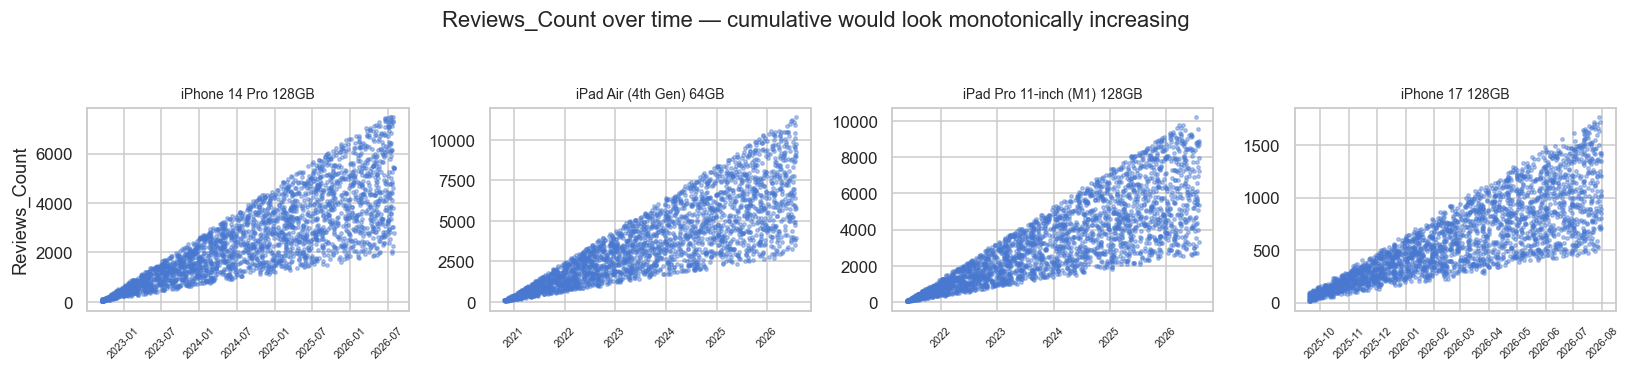

In [35]:
srt = df.sort_values('Date')
per_model = srt.groupby('Model_Name').agg(
    n_obs=('Reviews_Count', 'size'),
    spearman_time=('Reviews_Count', lambda s: s.reset_index(drop=True).corr(
        pd.Series(np.arange(len(s))), method='spearman')),
)
per_model['pct_non_decreasing'] = srt.groupby('Model_Name')['Reviews_Count'] \
    .apply(lambda s: s.diff().dropna().ge(0).mean())

print(per_model.round(3).to_string())
med_rho = per_model['spearman_time'].median()
med_mono = per_model['pct_non_decreasing'].median()
print(f"\nMedian Spearman(time, reviews) across models: {med_rho:.3f}")
print(f"Median share of non-decreasing consecutive steps: {med_mono:.3f}")

if med_rho > 0.8 and med_mono > 0.9:
    print("\nVERDICT: Reviews_Count behaves cumulatively -> it is largely a proxy for product age.")
    print("Expect strong collinearity with days_since_launch; keep only one of the two.")
else:
    print("\nVERDICT: Reviews_Count is NOT cumulative — counts fluctuate per listing snapshot.")
    print("The synthetic generator drew them (near-)randomly. It is at best a noisy popularity")
    print("proxy and at worst pure noise: expect weak association with the target (Section 3")
    print("table) and treat it as a drop candidate.")

# Visual: reviews over time for the 4 most-observed models
top4 = df['Model_Name'].value_counts().head(4).index
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=False)
for ax, m in zip(axes, top4):
    g = srt[srt['Model_Name'] == m]
    ax.scatter(g['Date'], g['Reviews_Count'], s=5, alpha=.4)
    ax.set_title(m, fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
axes[0].set_ylabel('Reviews_Count')
fig.suptitle('Reviews_Count over time — cumulative would look monotonically increasing', y=1.05)
plt.tight_layout()
plt.show()

## 5. Data quality flags and feature-selection summary

In [36]:
flags = []

# Leakage columns: already dropped at load (Section 0) — recorded here for completeness
for c in ['Current_Price_INR (target in INR)', 'Discount_Pct (derived from target)',
          'Launch_Price_INR (redundant with USD)']:
    flags.append((f'Leakage/redundancy: {c.split(" (")[0]}', c.split('(')[1].rstrip(')'),
                  'DROPPED at load — see Section 0'))

# Duplicates
exact = df.duplicated().sum()
flags.append(('Exact duplicate rows', f"{exact:,}",
              'drop before training' if exact else 'none — OK'))
key = df.duplicated(subset=['Date', 'Platform', 'Model_Name', 'Condition']).sum()
flags.append(('Duplicate (Date, Platform, Model, Condition) keys', f"{key:,}",
              'repeated observations per key — use time-based or grouped CV splits'))

# Highly correlated feature pairs (|rho| > 0.9)
feat_corr = df[NUM_FEATS].corr(method='spearman').abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
found = False
for a in upper.columns:
    for b, v in upper[a].dropna().items():
        if v > 0.9:
            flags.append((f'Correlated pair: {b} ~ {a}', f"|rho| = {v:.3f}", 'keep only one'))
            found = True
if not found:
    flags.append(('Highly correlated feature pairs (|rho| > 0.9)', 'none found', 'OK'))

# Near-zero variance
for col in df.columns:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if df[col].nunique(dropna=False) <= 1 or top_share > 0.99:
        flags.append((f'Near-zero variance: {col}', f"top value covers {top_share*100:.1f}%", 'no signal — drop'))

# Transformation needs (continuous columns only)
for col in ['Launch_Price_USD', 'Reviews_Count', 'storage_gb', 'days_since_launch', TARGET, RATIO]:
    sk = df[col].skew()
    if abs(sk) > 1:
        flags.append((f'Skewed column: {col}', f"skew = {sk:.2f}",
                      'consider log / rank transform for linear models'))

flags_df = pd.DataFrame(flags, columns=['Issue', 'Evidence', 'Implication'])
flags_df

,Issue,Evidence,Implication
0,Leakage/redundancy: Current_Price_INR,target in INR,DROPPED at load — see Section 0
1,Leakage/redundancy: Discount_Pct,derived from target,DROPPED at load — see Section 0
2,Leakage/redundancy: Launch_Price_INR,redundant with USD,DROPPED at load — see Section 0
3,Exact duplicate rows,0,none — OK
4,"Duplicate (Date, Platform, Model, Condition) keys","21,389",repeated observations per key — use time-based or grouped CV splits
5,Correlated pair: Launch_Price_USD ~ storage_gb,|rho| = 0.944,keep only one
6,Correlated pair: Reviews_Count ~ days_since_launch,|rho| = 0.908,keep only one
7,Skewed column: Launch_Price_USD,skew = 1.03,consider log / rank transform for linear models
8,Skewed column: Reviews_Count,skew = 1.25,consider log / rank transform for linear models
9,Skewed column: Current_Price_USD,skew = 1.11,consider log / rank transform for linear models


### Feature-selection summary for retention-ratio modeling

**Target:** `Retention_Ratio` (predicted price = ratio × known `Launch_Price_USD`). `Current_Price_USD` kept as a reference target for comparison experiments.

**Dropped at load (leakage / redundancy):** `Current_Price_INR`, `Discount_Pct`, `Launch_Price_INR` — see Section 0 note.

**Model_Name-agnostic feature set (deployable on unseen models like iPhone 19 128GB):**

| Feature | Role |
|---|---|
| `days_since_launch` | depreciation clock — core hypothesis driver |
| `Product_Category` | category-specific decay curves |
| `variant_tier`, `storage_gb`, `generation` | parsed from Model_Name — recover its signal without its cardinality |
| `Condition` | stable multiplier hypothesis |
| `Sale_Event` / `is_sale_event`, `month` | temporary festival dips, seasonality |
| `Platform`, `Stock_Status` | marketplace effects (check Section 3 tables for actual signal) |
| `Launch_Price_USD` | optional as a *feature* under the ratio target — test whether expensive products depreciate differently |

**Do not one-hot `Model_Name` itself** — unseen models would have no representation, and within-model constancy of launch price makes it partly redundant.

**`Rating` / `Reviews_Count`:** keep only if Section 3 shows real signal; see the Section 4 cumulative-nature verdict — if non-cumulative (synthetic noise), drop `Reviews_Count`.

**Validation:** time-based splits (train early, test late) — this both respects the repeated-observations structure and directly measures what the business needs: predicting retention for future dates and newly launched models.